<a href="https://colab.research.google.com/github/btkh95/CS610_AML_G5_Project/blob/main/AML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Prerequisites

In [ ]:
import os
import subprocess
import warnings
from pathlib import Path

import gdown
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive

warnings.filterwarnings("ignore")

drive.mount("/content/drive")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_info_columns', 200)

Mounted at /content/drive


In [ ]:
# README:
# add this folder in your google drive and add the file in that folder if you want to load the data from google drive instead of google sheets
# file = Path("/content/drive/My Drive/AML Project/Dataset/Dataset of health insurance portfolio.csv")
# file = Path("/content/drive/My Drive/AML Project/Dataset/")

# Otherwise you can run the code below, it will: (WARNING: Make sure you are in your school google account! You will have access to google colab xxxx.yyyy@smu.edu.sg)
# 1. Create the folder in your google drive if it doesn't exist
# 2. Copy the folder from the public google drive link to your google drive
# 3. Check that the required files exist in your google drive, if not it will download the missing files from the public google drive link to your google drive
# 4. Save the data to a parquet file in your google drive if it doesn't exist, otherwise it will load the data from the parquet file in your google drive

# Create "/My Drive/AML Project/Dataset/" folder in your google drive if it doesn't exist and add the file in that folder if you want to load the data from google drive instead of google sheets
dataset_folder = Path("/content/drive/MyDrive/AML Project/Dataset")
dataset_folder.mkdir(parents=True, exist_ok=True)

public_folder_url = "https://drive.google.com/drive/folders/1Ljll9i5uzlgrOz0imWcGlgGJq1tCwGxh"

# Query public folder without downloading
required_files = gdown.download_folder(
    url=public_folder_url,
    output=str(dataset_folder),
    quiet=True,
    skip_download=True
)

print("Files required from public folder:")
for file in required_files:
    print(file.path)

# Check which files are missing locally
missing_files = [
    file for file in required_files
    if not Path(file.local_path).exists()
]

if not missing_files:
    print("\nAll required files already exist. Skipping download.")
else:
    print("\nMissing files:")
    for file in missing_files:
        print(file.path)

    print("\nDownloading missing files only...")

    for file in missing_files:
        output_path = Path(file.local_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)

        gdown.download(
            id=file.id,
            output=str(output_path),
            quiet=False
        )

    print("\nMissing files downloaded successfully.")

Files required from public folder:
Centroid values of the climate clusters.xlsx
Dataset of health insurance portfolio
Dataset of health insurance portfolio.csv
Dataset of health insurance portfolio.xlsx
Descriptive of the variables.csv
Descriptive of the variables.xlsx
Division of Spanish regions into homogeneous climatological areas.pdf
percentile_reference_table.xlsx

All required files already exist. Skipping download.


In [ ]:
# Load from parquet if available; otherwise load from local CSV and save parquet for faster future loading.
dataset_folder_load = Path("/content/drive/MyDrive/AML Project/Dataset")
csv_file_path = dataset_folder_load / "Dataset of health insurance portfolio.csv"
parquet_file_path = dataset_folder_load / "Parquet" / "df.parquet"
parquet_file_path.parent.mkdir(parents=True, exist_ok=True)

if "df" in locals():
    print("DataFrame df already exists in memory.")

    if parquet_file_path.exists():
        print(f"Parquet file already exists at {parquet_file_path}.")
    else:
        try:
            print(f"Parquet file not found. Saving current df to {parquet_file_path}...")
            df.to_parquet(parquet_file_path)
            print("Current df saved to parquet successfully.")
        except Exception as e:
            print(f"An error occurred while saving df to parquet: {e}")

else:
    if parquet_file_path.exists():
        try:
            print(f"Loading data from parquet: {parquet_file_path}")
            df = pd.read_parquet(parquet_file_path)
            print("Data loaded from parquet successfully.")
        except Exception as e:
            print(f"An error occurred while loading parquet: {e}")

    else:
        try:
            print(f"Parquet file not found. Loading data from CSV: {csv_file_path}")
            df = pd.read_csv(csv_file_path)
            print("Data loaded from CSV successfully.")

            df.to_parquet(parquet_file_path)
            print(f"Data saved to parquet successfully at {parquet_file_path}.")
        except Exception as e:
            print(f"An error occurred while loading CSV or saving parquet: {e}")


Loading data from parquet: /content/drive/MyDrive/AML Project/Dataset/Parquet/df.parquet
Data loaded from parquet successfully.


## 2. Dataset Overview + Exploration

### High-level summary

A high-level look at the structure of the dataset — column types, value ranges, and record counts per year.

**Variable Groups**
| Group | Columns |
|---|---|
| Identifiers | `ID`, `ID_policy`, `ID_insured`, `period` |
| Dates & status | `date_effect_*`, `date_lapse_*`, `year_*`, `lapse`, `exposure_time` |
| Policy features | `type_policy`, `type_policy_dg`, `type_product`, `reimbursement`, `new_business`, `distribution_channel`, `seniority_insured`, `seniority_policy` |
| Demographics | `age`, `gender` |
| Financials | `premium`, `cost_claims_year`, `n_medical_services` |
| Portfolio / concentration | `n_insured_pc`, `n_insured_mun`, `n_insured_prov`, `IICIMUN`, `IICIPROV` |
| Socioeconomic (percentile) | `C_GI`, `C_II`, `C_IE_P`, `C_IE_S`, `C_IE_T`, `C_GE_P`, `C_GE_S`, `C_GE_T` |
| Geographic / climate | `C_H`, `C_C` |

In [ ]:
high_risk_registry = []

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [ ]:
profile_rows = []

for col in df.columns:
  dtype       = str(df[col].dtype)
  n_unique    = df[col].nunique(dropna=True)
  nulls       = df[col].isnull().sum()
  null_pct    = nulls / len(df) * 100

  samples_list = df[col].dropna().unique()[:5].tolist()
  samples_str  = ", ".join([f"'{str(s)[:20]}'" for s in samples_list])

  # RISK CHECK: High Missing Data
  if null_pct > 20.0:
    high_risk_registry.append({
      "Column": col,
      "Type": "All Types",
      "Risk Level": "HIGH",
      "Reason": f"High missingness: {null_pct:.1f}% of values are null."
    })

  profile_rows.append({
    "Column": col,
    "Data Type": dtype,
    "Unique Count": f"{n_unique:,}",
    "Missing Nulls (%)": f"{nulls:,} ({null_pct:.1f}%)",
    "Data Samples": f"[{samples_str}]"
  })
profile_df = pd.DataFrame(profile_rows)

print(profile_df.to_string(index=False))

              Column Data Type Unique Count Missing Nulls (%)                                                           Data Samples
                  ID    object      100,453          0 (0.0%)                                    ['1_1', '1_2', '2_1', '3_3', '3_5']
           ID_policy     int64       45,162          0 (0.0%)                                              ['1', '2', '3', '4', '5']
          ID_insured     int64        1,467          0 (0.0%)                                              ['1', '2', '3', '5', '6']
              period     int64            3          0 (0.0%)                                               ['2017', '2018', '2019']
 date_effect_insured    object        5,332          0 (0.0%) ['15 06 1993', '16 06 1993', '19 04 1999', '08 08 1995', '01 07 1993']
  date_lapse_insured    object          655   167,181 (73.1%) ['20 12 2017', '31 12 2017', '01 01 2017', '31 03 2017', '31 12 2019']
  date_effect_policy    object        3,268          0 (0.0%) ['15 06

### Row duplicates

In [ ]:
dupes = df.duplicated().sum()
print(f"\nExact duplicate rows: {dupes:,}  ({dupes / len(df) * 100:.2f}%)")

if dupes > 0:
  high_risk_registry.append({
    "Column": "Dataset Wide",
    "Type": "Duplication",
    "Risk Level": "MEDIUM",
    "Reason": f"Contains {dupes:,} redundant rows ({dupe_pct:.2f}%). Will cause data leak if not dropped."
  })


Exact duplicate rows: 0  (0.00%)


### Categorical columns

In [ ]:
cat_rows = []

for col in cat_cols:
  s        = df[col]
  n_unique = s.nunique(dropna=True)
  nulls    = s.isnull().sum()
  null_pct = nulls / len(df) * 100
  vc       = s.value_counts(dropna=True)

  # Force initialize separate categorical string placeholders to block bleedover
  cat_top_val   = "-"
  cat_top_count = "-"
  cat_notes     = ""

  if not vc.empty:
      cat_top_val   = str(vc.index[0])[:30]
      cat_top_cnt   = vc.values[0]
      cat_top_pct   = cat_top_cnt / len(df) * 100
      cat_top_count = f"{cat_top_cnt:,} ({cat_top_pct:.1f}%)"

      if cat_top_pct > 95.0 and len(df) > 10:
        high_risk_registry.append({
          "Column": col,
          "Type": "Categorical",
          "Risk Level": "MEDIUM",
          "Reason": f"Quasi-constant variable. Class '{cat_top_val}' dominates {cat_top_pct:.1f}% of entries."
        })

  if n_unique > 1:
      cat_notes = f"{n_unique:,} distinct categories"
  elif n_unique == 1:
      cat_notes = "Single value column"
      high_risk_registry.append({
        "Column": col,
        "Type": "Categorical",
        "Risk Level": "HIGH",
        "Reason": "Constant variable (only 1 unique value exists). Offers zero variance/information."
      })
  else:
      cat_notes = "Empty column"
      high_risk_registry.append({
        "Column": col,
        "Type": "Categorical",
        "Risk Level": "CRITICAL",
        "Reason": "Column is completely empty or consists entirely of missing data."
      })

  cat_rows.append({
      "Column": col,
      "Nulls": f"{nulls:,} ({null_pct:.1f}%)",
      "Unique Count": f"{n_unique:,}",
      "Top Category": cat_top_val,
      "Top Category Count (%)": cat_top_count,
      "Distribution Notes": cat_notes
  })

cat_df = pd.DataFrame(cat_rows)

print(cat_df.to_string(index=False))

              Column           Nulls Unique Count Top Category Top Category Count (%)          Distribution Notes
                  ID        0 (0.0%)      100,453      35618_4               3 (0.0%) 100,453 distinct categories
 date_effect_insured        0 (0.0%)        5,332   01 01 2017          10,976 (4.8%)   5,332 distinct categories
  date_lapse_insured 167,181 (73.1%)          655   31 12 2018          14,963 (6.5%)     655 distinct categories
  date_effect_policy        0 (0.0%)        3,268   01 01 2017          11,388 (5.0%)   3,268 distinct categories
   date_lapse_policy 174,568 (76.3%)          395   31 12 2018          14,133 (6.2%)     395 distinct categories
         type_policy        0 (0.0%)            2            I        145,471 (63.6%)       2 distinct categories
      type_policy_dg        0 (0.0%)            6            I        115,210 (50.4%)       6 distinct categories
        type_product        0 (0.0%)            4            S        175,415 (76.7%)   

### Numerical columns

In [ ]:
flagged_skew  = []
flagged_zeros = []
skew_threshold = 1.0
table_rows    = []
flag_str = ""
notes_str = ""

for col in num_cols:
  s       = df[col]
  skew    = s.skew()
  mn      = s.min()
  mx      = s.max()
  mean    = s.mean()
  median  = s.median()
  p25     = s.quantile(0.25)
  p75     = s.quantile(0.75)
  zeros   = (s == 0).sum()
  zero_p  = zeros / len(df) * 100
  neg     = (s < 0).sum()

  num_flags = []
  num_notes = []

  # Build flags for the table
  if abs(skew) >= skew_threshold:
    num_flags.append("HIGH SKEW")
    direction = "right" if skew > 0 else "left"
    num_notes.append(f"{direction}-skewed ({skew:.3f})")
    high_risk_registry.append({
      "Column": col,
      "Type": "Numeric",
      "Risk Level": "MEDIUM",
      "Reason": f"Heavy {direction} skewness ({skew:.3f}). Distorts basic linear modeling."
    })

  if zeros > 0:
    num_flags.append("HAS ZEROS")
    num_notes.append(f"{zeros:,} zeros ({zero_p:.1f}%)")

  if neg > 0:
    num_flags.append("HAS NEGATIVES")
    high_risk_registry.append({
      "Column": col,
      "Type": "Numeric",
      "Risk Level": "HIGH",
      "Reason": f"Contains {neg:,} negative values. Investigate if field should strictly be positive (e.g., age, premium)."
    })

  flag_str = ", ".join(num_flags) if num_flags else "-"
  notes_str = "; ".join(num_notes) if num_notes else ""

  # Collect row data for the main table
  table_rows.append({
    "Column": col,
    "Min": f"{mn:.4g}",
    "Max": f"{mx:.4g}",
    "Mean": f"{mean:.4g}",
    "Median": f"{median:.4g}",
    "p25/p75": f"{p25:.4g} / {p75:.4g}",
    "Skewness": f"{skew:.3f}",
    "Zeros": f"{zeros:,} ({zero_p:.1f}%)",
    "Flags": flag_str,
    "Summary Notes": notes_str
  })

summary_df = pd.DataFrame(table_rows)

print(summary_df.to_string(index=False))

             Column   Min       Max      Mean   Median          p25/p75 Skewness          Zeros                Flags                               Summary Notes
          ID_policy     1 4.516e+04 2.063e+04 2.05e+04 9800 / 3.131e+04    0.047       0 (0.0%)                    -                                            
         ID_insured     1      1886     13.94        2            1 / 3   11.211       0 (0.0%)            HIGH SKEW                       right-skewed (11.211)
             period  2017      2019      2018     2018      2017 / 2019    0.018       0 (0.0%)                    -                                            
year_effect_insured  1933      2019      2005     2009      1996 / 2016   -1.340       0 (0.0%)            HIGH SKEW                        left-skewed (-1.340)
 year_lapse_insured  2017      2019      2018     2018      2018 / 2019   -0.282       0 (0.0%)                    -                                            
 year_effect_policy  1932      201

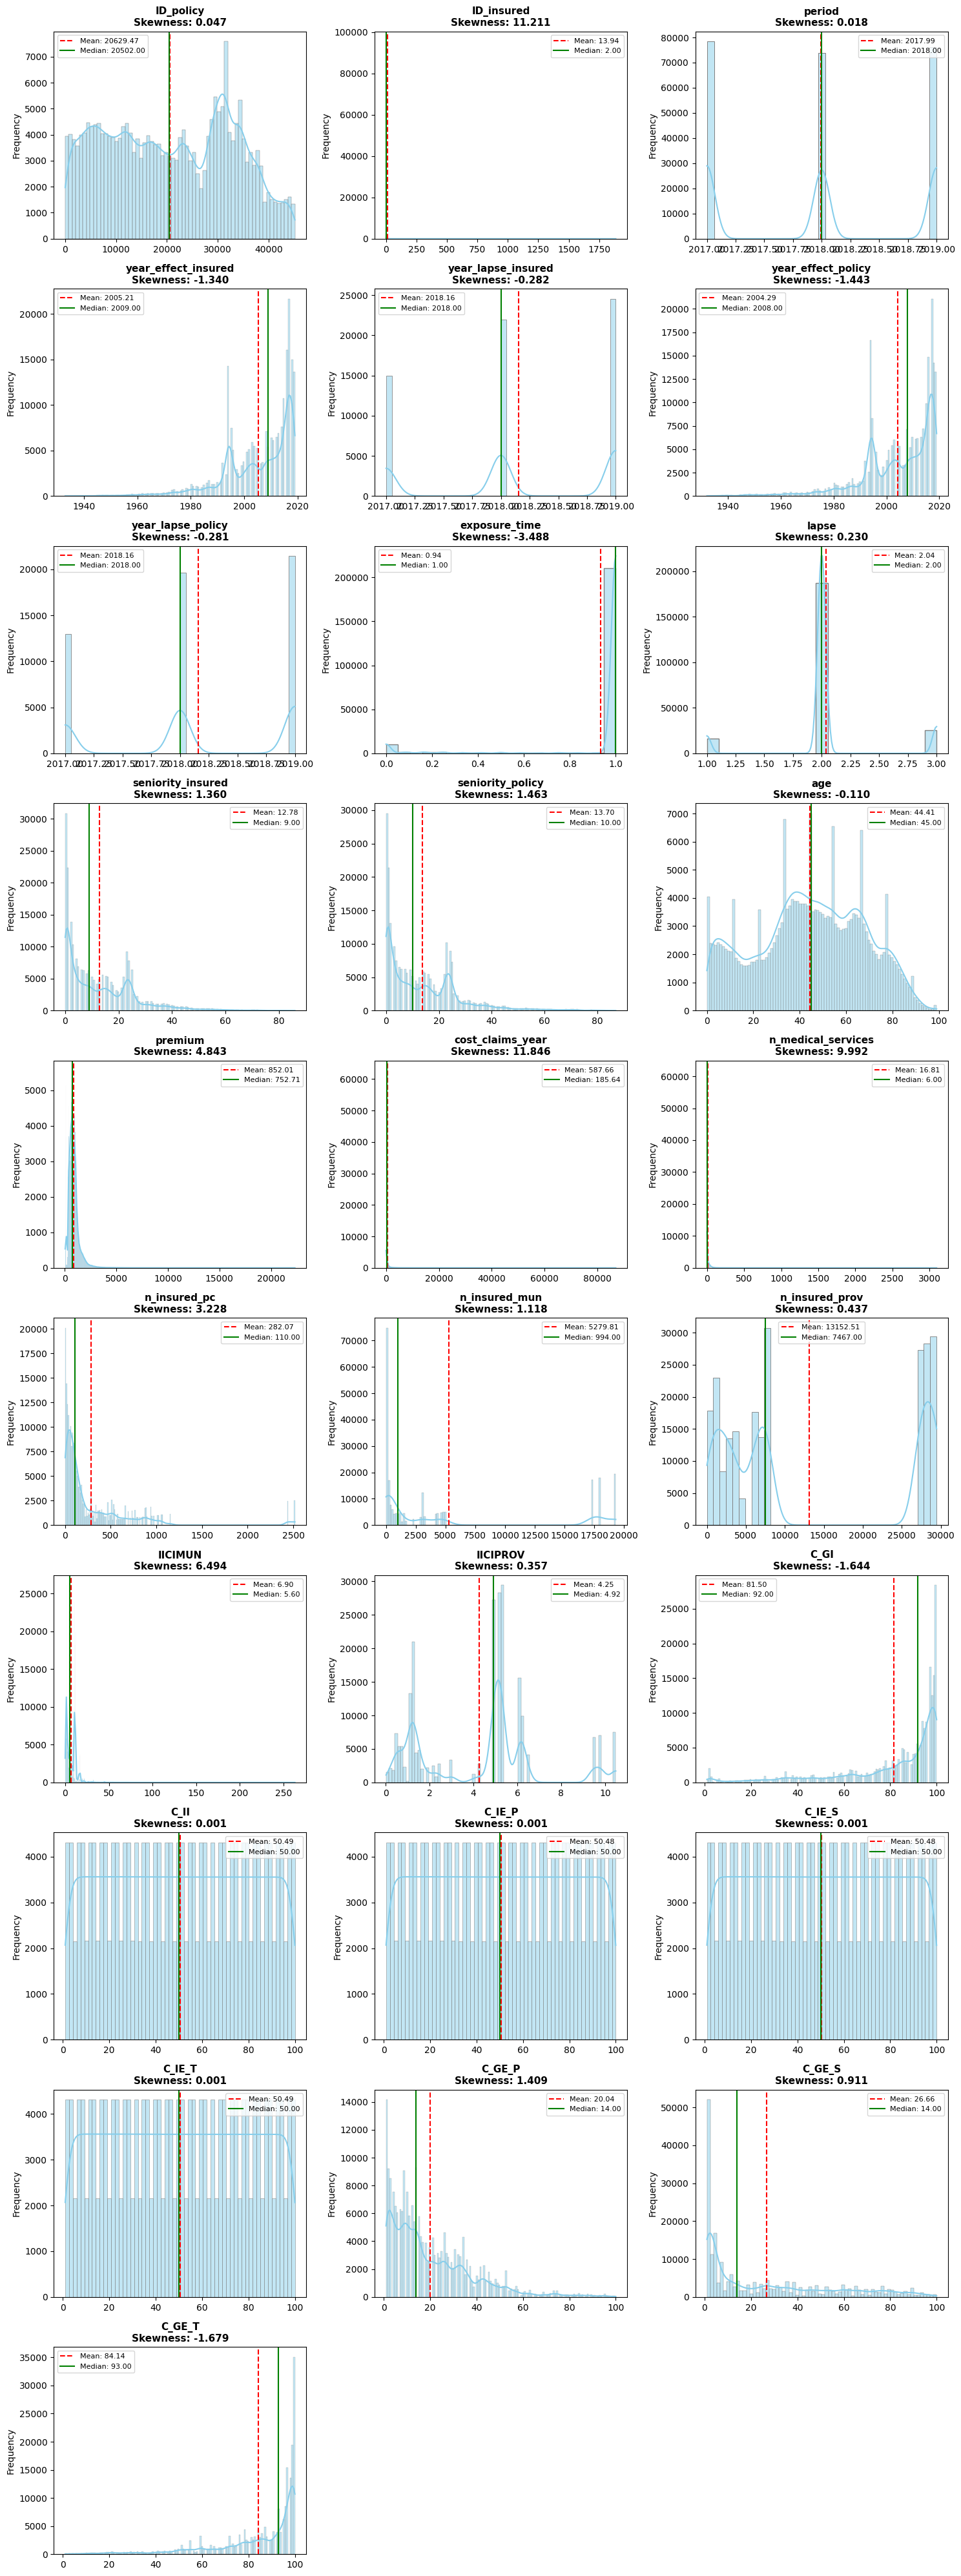

In [ ]:
if num_cols:
  # Dynamically determine grid size (3 columns wide)
  n_plots = len(num_cols)
  n_plot_cols = 3
  n_plot_rows = (n_plots + n_plot_cols - 1) // n_plot_cols

  # Setup the matplotlib figure canvas
  fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(5 * n_plot_cols, 4 * n_plot_rows))

  # Ensure axes is a flat array even if it's a 1x1 or a 1D grid
  if n_plots == 1:
    axes = [axes]
  else:
    axes = axes.flatten()

  # Loop through columns and populate the grid
  for idx, col in enumerate(num_cols):
    ax = axes[idx]
    skew_val = df[col].skew()

    # Plot Histogram with a smooth distribution curve (KDE)
    sns.histplot(df[col], kde=True, ax=ax, color="skyblue", edgecolor="gray")

    # Add a vertical line for Mean (Red dashed) and Median (Green solid)
    ax.axvline(df[col].mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean: {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="green", linestyle="-", linewidth=1.5, label=f"Median: {df[col].median():.2f}")

    ax.set_title(f"{col}\nSkewness: {skew_val:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

  # Hide any unused subplots in the grid layout
  for idx in range(n_plots, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

### Correlations (Numerical columns)

In [ ]:
corr = df[num_cols].corr()
pairs = []
corr_threshold = 0.7

for i, c1 in enumerate(corr.columns):
    for c2 in corr.columns[i + 1:]:
        r = corr.loc[c1, c2]
        if abs(r) >= corr_threshold:
            pairs.append((c1, c2, round(r, 4)))

if pairs:
    pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)
    print(f"\n  {'Column A':<30} {'Column B':<30} {'r':>8}  Strength")
    print(f"  {'-'*30} {'-'*30} {'-'*8}  --------")
    for c1, c2, r in pairs_sorted:
        if abs(r) >= 0.9:
            strength = "VERY HIGH"
            # RISK CHECK: Collinearity warning
            high_risk_registry.append({
                "Column": f"{c1} & {c2}",
                "Type": "Correlation",
                "Risk Level": "MEDIUM",
                "Reason": f"Extreme collinearity (r = {r:.2f}). Consider dropping one column to fix model inflation."
            })
        elif abs(r) >= 0.7:
            strength = "HIGH"
        else:
            strength = "MODERATE"
        direction = "pos" if r > 0 else "neg"
        print(f"  {c1:<30} {c2:<30} {r:>8.4f}  {strength} ({direction})")
else:
    print(f"\n  No pairs found above |r| = {corr_threshold}")

print("FULL CORRELATION MATRIX (numeric columns)")

print(corr.to_string())


  Column A                       Column B                              r  Strength
  ------------------------------ ------------------------------ --------  --------
  year_effect_policy             seniority_policy                -0.9983  VERY HIGH (neg)
  year_effect_insured            seniority_insured               -0.9980  VERY HIGH (neg)
  year_lapse_insured             year_lapse_policy                0.9823  VERY HIGH (pos)
  C_IE_S                         C_IE_T                          -0.9621  VERY HIGH (neg)
  year_effect_insured            year_effect_policy               0.9604  VERY HIGH (pos)
  seniority_insured              seniority_policy                 0.9601  VERY HIGH (pos)
  year_effect_insured            seniority_policy                -0.9585  VERY HIGH (neg)
  year_effect_policy             seniority_insured               -0.9583  VERY HIGH (neg)
  C_IE_S                         C_GE_S                           0.9293  VERY HIGH (pos)
  C_IE_P               

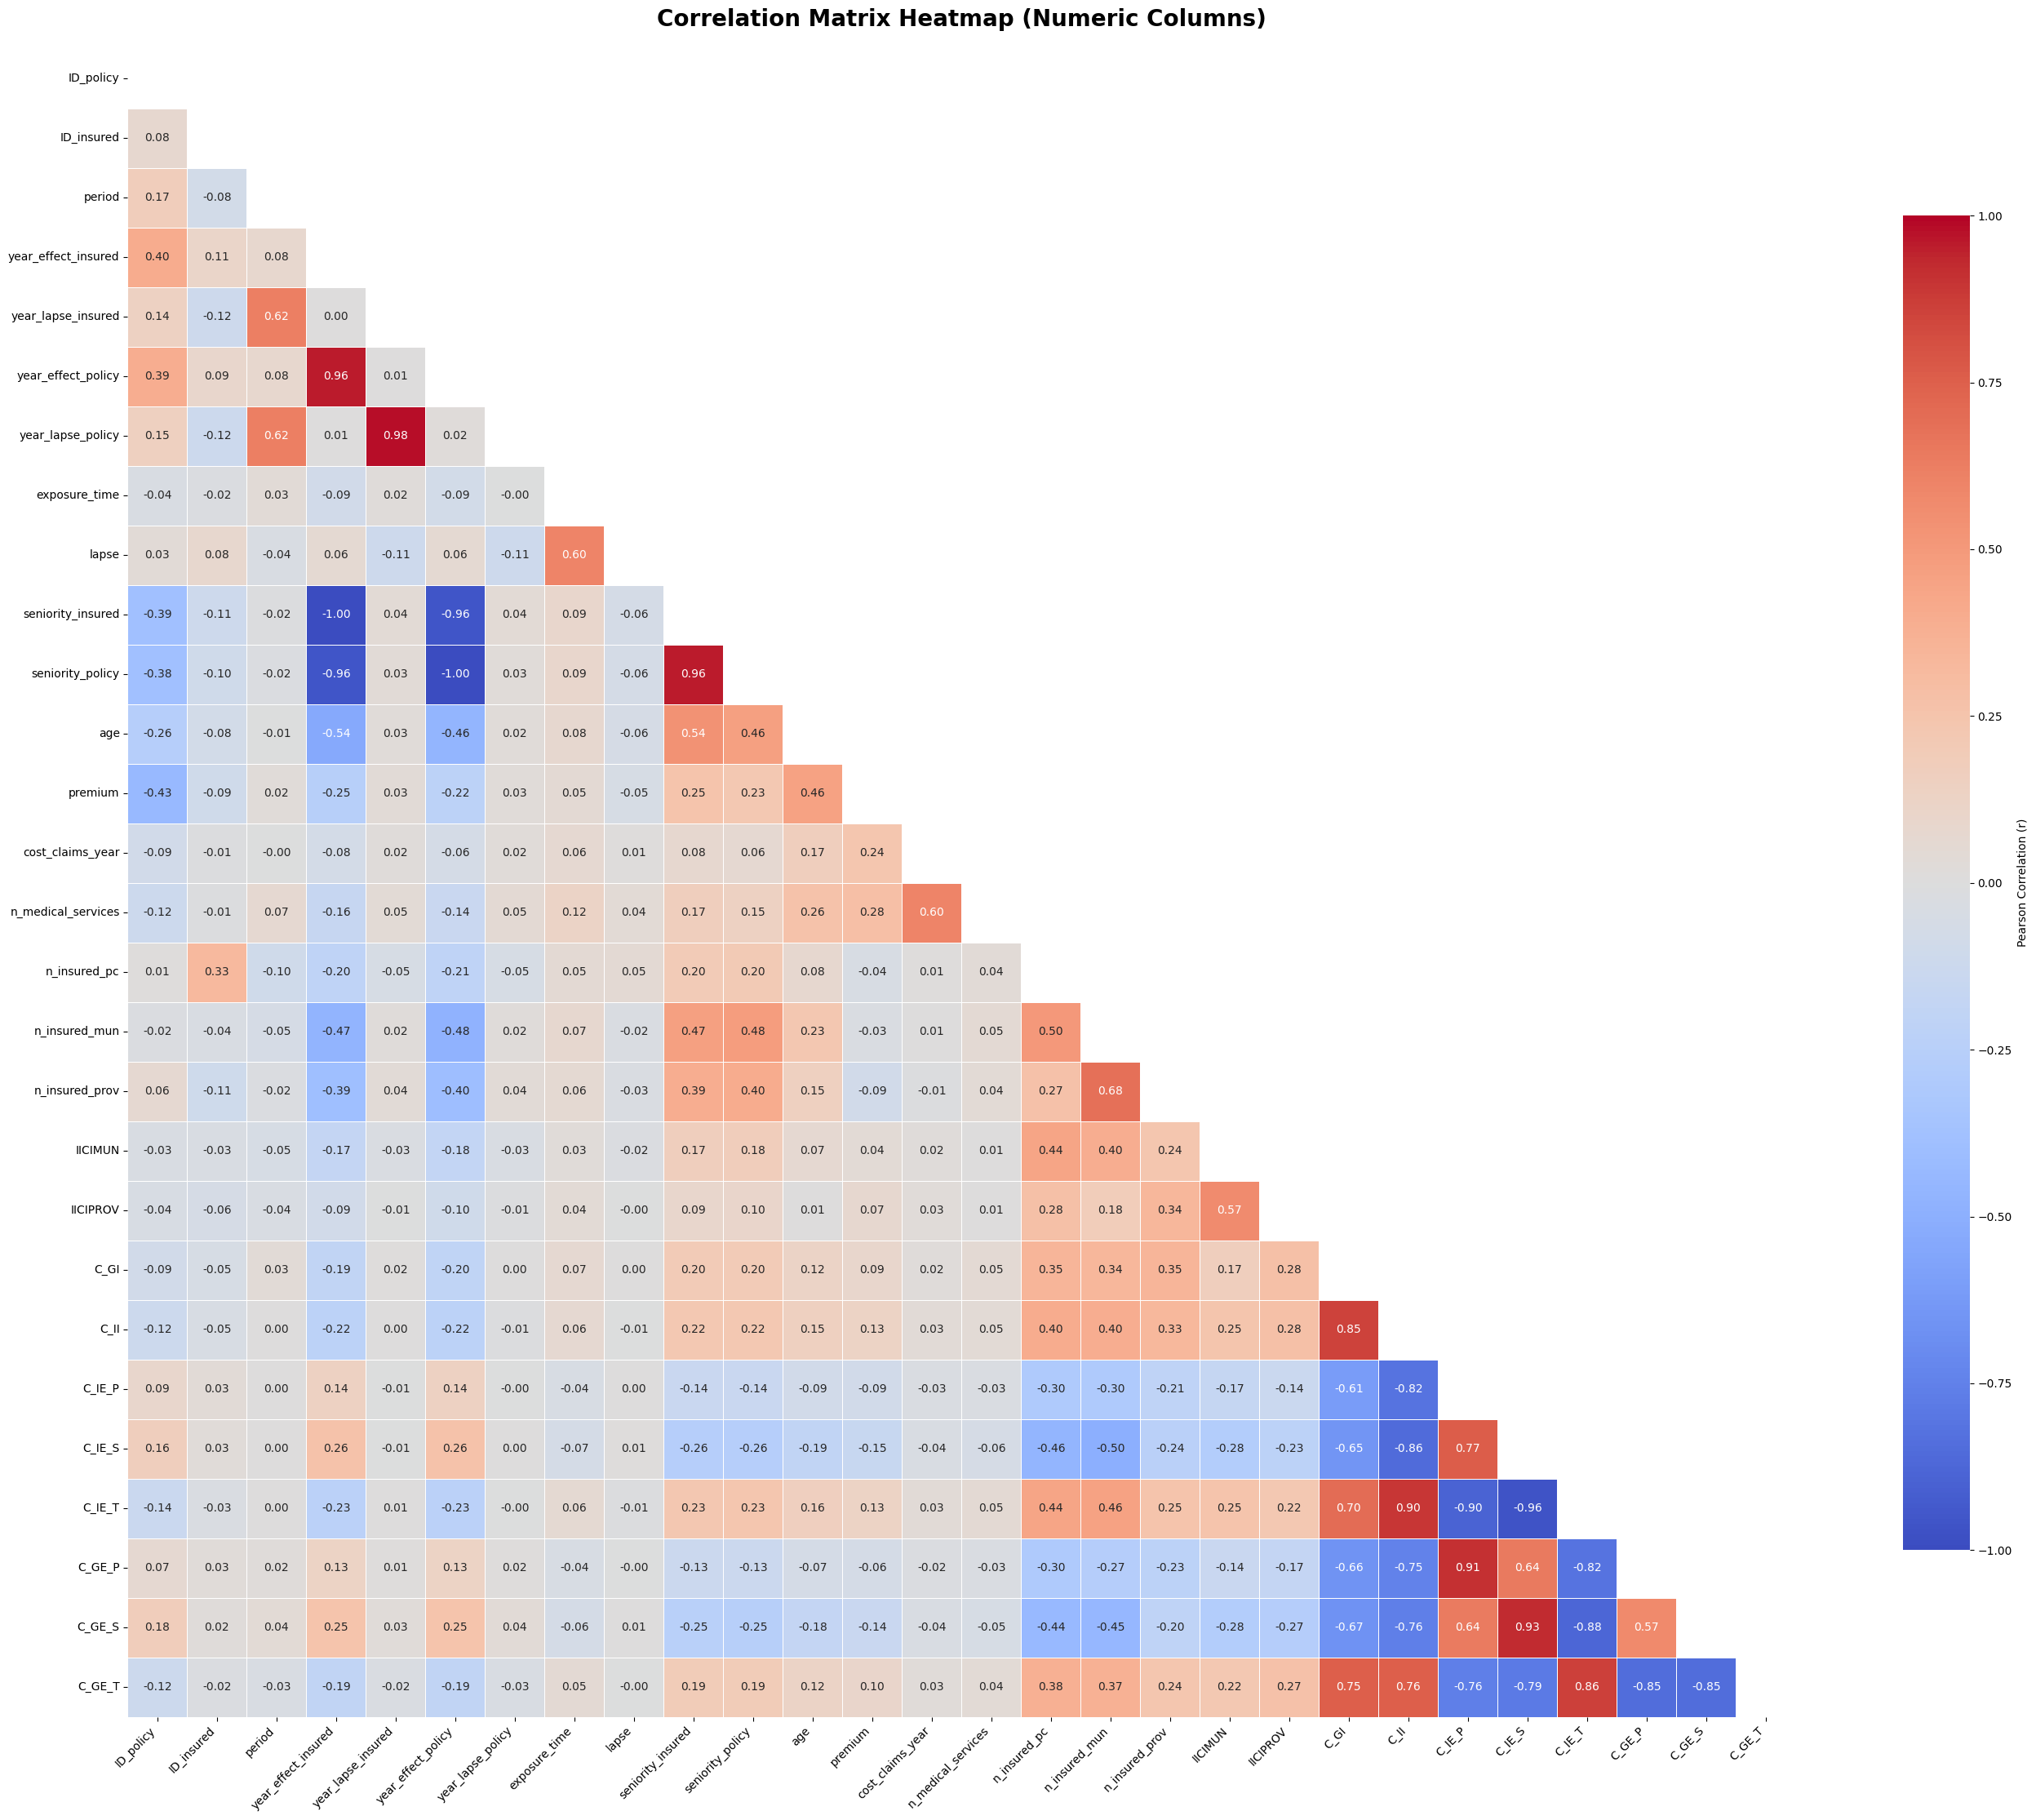

In [ ]:
if len(num_cols) > 1:
  # Calculate dynamic figure size based on the number of numeric columns
  fig_size = max(5, len(num_cols))
  plt.figure(figsize=(fig_size, fig_size * 0.8))

  # Generate a mask to hide the upper triangle (since correlation matrices are symmetrical)
  mask = np.triu(np.ones_like(corr, dtype=bool))

  # Plot the heatmap using a divergent color palette (coolwarm centers at 0)
  sns.heatmap(
      corr,
      mask=mask,
      annot=True,             # Add the Pearson correlation coefficient values inside the cells
      fmt=".2f",              # Round values to two decimal places
      cmap="coolwarm",        # Blue = Negative correlation, Red = Positive correlation
      vmin=-1, vmax=1,        # Lock scale anchors to standard correlation limits
      square=True,            # Make cells perfectly square
      linewidths=0.5,         # Put thin borders between the cells
      cbar_kws={"shrink": 0.8, "label": "Pearson Correlation (r)"} # Customize the side color bar
  )

  plt.title("Correlation Matrix Heatmap (Numeric Columns)", fontsize=20, fontweight="bold", pad=20)
  plt.xticks(rotation=45, ha='right') # Rotate labels to avoid text overlap
  plt.yticks(rotation=0)
  plt.tight_layout()

### Risk report

In [ ]:
if high_risk_registry:
  risk_df = pd.DataFrame(high_risk_registry)

  # Sort by gravity so Critical and High float to top
  level_order = {"CRITICAL": 0, "HIGH": 1, "MEDIUM": 2}
  risk_df["_sort_key"] = risk_df["Risk Level"].map(level_order)
  risk_df = risk_df.sort_values("_sort_key").drop(columns=["_sort_key"])

  print(risk_df.to_string(index=False))
else:
  print("\n All good.")

                                  Column        Type Risk Level                                                                                 Reason
                      date_lapse_insured   All Types       HIGH                                            High missingness: 73.1% of values are null.
                       date_lapse_policy   All Types       HIGH                                            High missingness: 76.3% of values are null.
                      year_lapse_insured   All Types       HIGH                                            High missingness: 73.1% of values are null.
                       year_lapse_policy   All Types       HIGH                                            High missingness: 76.3% of values are null.
                              ID_insured     Numeric     MEDIUM                         Heavy right skewness (11.211). Distorts basic linear modeling.
                     year_effect_insured     Numeric     MEDIUM                          Heavy

## 3. Dataset Cleanup

In [ ]:
# 1. Keep only Standard and Premium
df_sp = df[df["type_product"].isin(["S", "P"])]

# 2. Identify customers (ID) that appear in all three years 2017, 2018, 2019
years_per_id = df_sp.groupby("ID")["period"].nunique()
keep_ids = years_per_id[years_per_id == 3].index

df_project = df_sp[df_sp["ID"].isin(keep_ids)].copy()

In [ ]:
print("Original shape:", df.shape)
print("Project subset shape:  ", df_project.shape)

print("\nOriginal columns:")
print(df.columns.tolist())

print("\nProject subset columns:")
print(df_project.columns.tolist())

Original shape: (228711, 42)
Project subset shape:   (157365, 42)

Original columns:
['ID', 'ID_policy', 'ID_insured', 'period', 'date_effect_insured', 'date_lapse_insured', 'date_effect_policy', 'date_lapse_policy', 'year_effect_insured', 'year_lapse_insured', 'year_effect_policy', 'year_lapse_policy', 'exposure_time', 'lapse', 'seniority_insured', 'seniority_policy', 'type_policy', 'type_policy_dg', 'type_product', 'reimbursement', 'new_business', 'distribution_channel', 'gender', 'age', 'premium', 'cost_claims_year', 'n_medical_services', 'n_insured_pc', 'n_insured_mun', 'n_insured_prov', 'IICIMUN', 'IICIPROV', 'C_H', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_S', 'C_IE_T', 'C_GE_P', 'C_GE_S', 'C_GE_T', 'C_C']

Project subset columns:
['ID', 'ID_policy', 'ID_insured', 'period', 'date_effect_insured', 'date_lapse_insured', 'date_effect_policy', 'date_lapse_policy', 'year_effect_insured', 'year_lapse_insured', 'year_effect_policy', 'year_lapse_policy', 'exposure_time', 'lapse', 'seniority_insure

In [ ]:
print("=== df_project.describe() — numeric columns ===")
print(df_project.describe().T.to_string())

print("\n=== df_project.describe() — object/categorical columns ===")
print(df_project.describe(include='object').T.to_string())

=== df_project.describe() — numeric columns ===
                        count          mean           std      min      25%       50%         75%       max
ID_policy            157365.0  16880.496692  10441.528168     1.00  7792.00  16121.00  24571.0000  35618.00
ID_insured           157365.0      2.724202      4.965237     1.00     1.00      2.00      3.0000    125.00
period               157365.0   2018.000000      0.816499  2017.00  2017.00   2018.00   2019.0000   2019.00
year_effect_insured  157365.0   2002.067391     13.250107  1933.00  1994.00   2004.00   2013.0000   2017.00
year_lapse_insured    19222.0   2018.901467      0.298042  2018.00  2019.00   2019.00   2019.0000   2019.00
year_effect_policy   157365.0   2000.978401     14.266790  1932.00  1994.00   2003.00   2013.0000   2017.00
year_lapse_policy     16123.0   2018.901445      0.298073  2018.00  2019.00   2019.00   2019.0000   2019.00
exposure_time        157365.0      0.972771      0.158084     0.00     1.00      1.00   

In [ ]:
# All rows:
# ['ID', 'ID_policy', 'ID_insured', 'period', 'date_effect_insured', 'date_lapse_insured', 'date_effect_policy', 'date_lapse_policy',
# 'year_effect_insured', 'year_lapse_insured', 'year_effect_policy', 'year_lapse_policy', 'exposure_time', 'lapse', 'seniority_insured',
# 'seniority_policy', 'type_policy', 'type_policy_dg', 'type_product', 'reimbursement', 'new_business', 'distribution_channel',
# 'gender', 'age', 'premium', 'cost_claims_year', 'n_medical_services', 'n_insured_pc', 'n_insured_mun', 'n_insured_prov', 'IICIMUN', 'IICIPROV',
# 'C_H', 'C_GI', 'C_II', 'C_IE_P', 'C_IE_S', 'C_IE_T', 'C_GE_P', 'C_GE_S', 'C_GE_T', 'C_C']


# Keep Relevant Rows
df_project_clean = df_project[
    [
        'ID',                    # policy + insured identifier
        'ID_policy',             # policy identifier
        'ID_insured',            # insured identifier
        'period',                # year of observation (2017, 2018, 2019)
        'date_effect_insured',   # date when the insured became effective
        'date_lapse_insured',    # date when the insured lapsed
        'date_effect_policy',    # date when the policy became effective
        'date_lapse_policy',     # date when the policy lapsed
        'year_effect_insured',   # year when the insured became effective
        'year_lapse_insured',    # year when the insured lapsed
        'year_effect_policy',    # year when the policy became effective
        'year_lapse_policy',     # year when the policy lapsed
        'exposure_time',         # length of year exposed to risk (between 0 and 1)
        'lapse',                 # indicator for whether the policy lapsed
        'seniority_insured',     # years of seniority for the insured
        'seniority_policy',      # years of seniority for the policy
        'type_policy',           # type of policy
        'type_policy_dg',        # type of policy (detailed)
        'type_product',          # type of product
        'reimbursement',         # reimbursement amount
        'new_business',          # indicator for new business
        'distribution_channel',  # distribution channel
        'gender',                # gender of the insured
        'age',                   # age of the insured
        'premium',               # premium amount
        'cost_claims_year',      # annual cost of claims
        'n_medical_services',    # number of medical services
        'n_insured_pc',          # number of insured in a particular category
        'n_insured_mun',         # number of insured in a particular municipality
        'n_insured_prov',        # number of insured in a particular province
        'IICIMUN',               # index for municipal-level insurance
        'IICIPROV',              # index for provincial-level insurance
        'C_H',                   # Habitat Size
        'C_GI',                  # Geographic Index
        'C_II',                  # Income Index
        'C_IE_P',                # Educational Index - Private
        'C_IE_S',                # Educational Index - Social
        'C_IE_T',                # Educational Index - Technical
        'C_GE_P',                # Gender Index - Private
        'C_GE_S',                # Gender Index - Social
        'C_GE_T',                # Gender Index - Technical
        'C_C']]                  # Category Index

In [ ]:
# Step 1: Create target variable
df_project_clean["unprofitable"] = (
    df_project_clean["cost_claims_year"] > df_project_clean["premium"]
).astype(int)

print(f"Target created. Unprofitable rate: {df_project_clean['unprofitable'].mean()*100:.1f}%")


Target created. Unprofitable rate: 17.0%


In [ ]:
# Step 2: Train / test split by year
# Train on 2017-2018, test on 2019 (temporal split before fitted preprocessing).

train = df_project_clean[df_project_clean["period"].isin([2017, 2018])].copy()
test = df_project_clean[df_project_clean["period"] == 2019].copy()

print(f"Train set : {len(train):,} rows  ({len(train)/len(df_project_clean)*100:.1f}%)")
print(f"Test set  : {len(test):,} rows  ({len(test)/len(df_project_clean)*100:.1f}%)")
print()
print(f"Train unprofitable rate : {train['unprofitable'].mean()*100:.1f}%")
print(f"Test  unprofitable rate : {test['unprofitable'].mean()*100:.1f}%")


Train set : 104,910 rows  (66.7%)
Test set  : 52,455 rows  (33.3%)

Train unprofitable rate : 17.7%
Test  unprofitable rate : 15.5%


In [ ]:
# Step 3: Handle missing values
# Fit imputation values on train only, then apply the same values to test.

socio_cols = ["C_GI", "C_II", "C_IE_P", "C_IE_S", "C_IE_T", "C_GE_P", "C_GE_S", "C_GE_T"]
geo_cols = ["C_H", "C_C"]
concentration_cols = ["IICIMUN", "IICIPROV"]
missing_check_cols = socio_cols + geo_cols + concentration_cols

print("Missing values before imputation - train:")
print(train[missing_check_cols].isnull().sum())
print("\nMissing values before imputation - test:")
print(test[missing_check_cols].isnull().sum())

# Missing indicators before filling values.
train["geo_missing_flag"] = train[geo_cols].isnull().any(axis=1).astype(int)
test["geo_missing_flag"] = test[geo_cols].isnull().any(axis=1).astype(int)

# Numeric imputation: train medians only.
median_impute_cols = socio_cols + concentration_cols
train_medians = train[median_impute_cols].median()
train[median_impute_cols] = train[median_impute_cols].fillna(train_medians)
test[median_impute_cols] = test[median_impute_cols].fillna(train_medians)

# Categorical imputation: train modes only.
train_modes = train[geo_cols].mode().iloc[0]
train[geo_cols] = train[geo_cols].fillna(train_modes)
test[geo_cols] = test[geo_cols].fillna(train_modes)

print("\nMissing values after imputation - train:")
print(train[missing_check_cols].isnull().sum())
print("\nMissing values after imputation - test:")
print(test[missing_check_cols].isnull().sum())


Missing values before imputation - train:
C_GI        5388
C_II        5388
C_IE_P      5388
C_IE_S      5388
C_IE_T      5388
C_GE_P      5388
C_GE_S      5388
C_GE_T      5388
C_H         4070
C_C         3843
IICIMUN     4070
IICIPROV    1338
dtype: int64

Missing values before imputation - test:
C_GI        2694
C_II        2694
C_IE_P      2694
C_IE_S      2694
C_IE_T      2694
C_GE_P      2694
C_GE_S      2694
C_GE_T      2694
C_H         2035
C_C         2015
IICIMUN     2035
IICIPROV     669
dtype: int64

Missing values after imputation - train:
C_GI        0
C_II        0
C_IE_P      0
C_IE_S      0
C_IE_T      0
C_GE_P      0
C_GE_S      0
C_GE_T      0
C_H         0
C_C         0
IICIMUN     0
IICIPROV    0
dtype: int64

Missing values after imputation - test:
C_GI        0
C_II        0
C_IE_P      0
C_IE_S      0
C_IE_T      0
C_GE_P      0
C_GE_S      0
C_GE_T      0
C_H         0
C_C         0
IICIMUN     0
IICIPROV    0
dtype: int64


In [ ]:
# Step 4: Encode categorical variables
# Encode using mappings learned from train only, then apply to test.

from sklearn.preprocessing import LabelEncoder

# Ordinal encode C_H (natural order: H1=1 ... H6=6)
habitat_order = {"H1": 1, "H2": 2, "H3": 3, "H4": 4, "H5": 5, "H6": 6}
train["C_H_encoded"] = train["C_H"].map(habitat_order)
test["C_H_encoded"] = test["C_H"].map(habitat_order)

cat_cols = [
    "type_policy", "type_policy_dg", "type_product",
    "reimbursement", "new_business", "distribution_channel",
    "gender", "C_C"
]

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(train[col].astype(str))
    label_encoders[col] = le

    train[f"{col}_encoded"] = le.transform(train[col].astype(str))

    # If a test category was unseen in train, mark it as -1 instead of crashing.
    mapping = {label: code for code, label in enumerate(le.classes_)}
    test[f"{col}_encoded"] = test[col].astype(str).map(mapping).fillna(-1).astype(int)

print("Encoded columns added:")
print([c for c in train.columns if c.endswith("_encoded")])


Encoded columns added:
['C_H_encoded', 'type_policy_encoded', 'type_policy_dg_encoded', 'type_product_encoded', 'reimbursement_encoded', 'new_business_encoded', 'distribution_channel_encoded', 'gender_encoded', 'C_C_encoded']


In [ ]:
# Step 5: Define feature sets

# Excluded from modelling: identifiers, dates, target/leakage columns, and raw categorical columns after encoding.
ID_COLS = ["ID", "ID_policy", "ID_insured"]
DATE_COLS = [
    "date_effect_insured", "date_lapse_insured", "date_effect_policy", "date_lapse_policy",
    "year_effect_insured", "year_lapse_insured", "year_effect_policy", "year_lapse_policy"
]
RAW_CAT_COLS = ["type_policy", "type_policy_dg", "type_product", "reimbursement", "new_business", "distribution_channel", "gender", "C_H", "C_C"]

BASE_FEATURES = [
    # Demographics
    "age", "gender_encoded",
    # Policy features
    "type_policy_encoded", "type_policy_dg_encoded", "type_product_encoded",
    "reimbursement_encoded", "new_business_encoded", "distribution_channel_encoded",
    "premium", "seniority_insured", "seniority_policy", "exposure_time",
    # Portfolio / concentration
    "n_insured_pc", "n_insured_mun", "n_insured_prov", "IICIMUN", "IICIPROV",
    # Socioeconomic
    "C_GI", "C_II", "C_IE_P", "C_IE_S", "C_IE_T", "C_GE_P", "C_GE_S", "C_GE_T",
    # Geographic
    "C_H_encoded", "C_C_encoded",
    # Missing flag
    "geo_missing_flag"
]

REGRESSION_TARGET = "cost_claims_year"
CLASSIFICATION_TARGET = "unprofitable"

# Cost claims defines the classification target, so it is not included in X.
# Premium is also removed for the classification task because unprofitable is defined using premium.
REGRESSION_FEATURES = [f for f in BASE_FEATURES if f != "premium"]
CLASSIFICATION_FEATURES = [f for f in BASE_FEATURES if f != "premium"]

print(f"Base feature count           : {len(BASE_FEATURES)}")
print(f"Regression feature count     : {len(REGRESSION_FEATURES)}")
print(f"Classification feature count : {len(CLASSIFICATION_FEATURES)}")


Base feature count           : 28
Regression feature count     : 27
Classification feature count : 27


In [ ]:
# Step 6: Create X/y datasets

X_train_reg = train[REGRESSION_FEATURES].copy()
y_train_reg = train[REGRESSION_TARGET].copy()
X_test_reg = test[REGRESSION_FEATURES].copy()
y_test_reg = test[REGRESSION_TARGET].copy()

X_train_clf = train[CLASSIFICATION_FEATURES].copy()
y_train_clf = train[CLASSIFICATION_TARGET].copy()
X_test_clf = test[CLASSIFICATION_FEATURES].copy()
y_test_clf = test[CLASSIFICATION_TARGET].copy()

print("Regression X/y:", X_train_reg.shape, y_train_reg.shape, X_test_reg.shape, y_test_reg.shape)
print("Classification X/y:", X_train_clf.shape, y_train_clf.shape, X_test_clf.shape, y_test_clf.shape)


Regression X/y: (104910, 27) (104910,) (52455, 27) (52455,)
Classification X/y: (104910, 27) (104910,) (52455, 27) (52455,)


In [ ]:
# Step 7: Scale numeric features (for logistic regression and K-Means)
# Fit scaler on train only, then transform train and test.

from sklearn.preprocessing import StandardScaler

NUMERIC_FEATURES = [
    "age", "seniority_insured", "seniority_policy", "exposure_time",
    "n_insured_pc", "n_insured_mun", "n_insured_prov", "IICIMUN", "IICIPROV",
    "C_GI", "C_II", "C_IE_P", "C_IE_S", "C_IE_T", "C_GE_P", "C_GE_S", "C_GE_T"
]

numeric_features_to_scale = [c for c in NUMERIC_FEATURES if c in X_train_clf.columns]

scaler = StandardScaler()
X_train_clf_scaled = X_train_clf.copy()
X_test_clf_scaled = X_test_clf.copy()
X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()

X_train_clf_scaled[numeric_features_to_scale] = scaler.fit_transform(X_train_clf[numeric_features_to_scale])
X_test_clf_scaled[numeric_features_to_scale] = scaler.transform(X_test_clf[numeric_features_to_scale])

reg_numeric_features_to_scale = [c for c in NUMERIC_FEATURES if c in X_train_reg.columns]
reg_scaler = StandardScaler()
X_train_reg_scaled[reg_numeric_features_to_scale] = reg_scaler.fit_transform(X_train_reg[reg_numeric_features_to_scale])
X_test_reg_scaled[reg_numeric_features_to_scale] = reg_scaler.transform(X_test_reg[reg_numeric_features_to_scale])

print("Scaling complete.")
print(f"Classification scaled numeric features: {len(numeric_features_to_scale)}")
print(f"Regression scaled numeric features    : {len(reg_numeric_features_to_scale)}")
print("Use scaled X sets for logistic regression / K-Means; use unscaled X sets for tree-based models.")


Scaling complete.
Classification scaled numeric features: 17
Regression scaled numeric features    : 17
Use scaled X sets for logistic regression / K-Means; use unscaled X sets for tree-based models.


In [ ]:
# Step 8: Preprocessing validation checks

checks = {
    "X_train_clf missing values": X_train_clf.isnull().sum().sum(),
    "X_test_clf missing values": X_test_clf.isnull().sum().sum(),
    "X_train_reg missing values": X_train_reg.isnull().sum().sum(),
    "X_test_reg missing values": X_test_reg.isnull().sum().sum(),
}

for name, value in checks.items():
    print(f"{name}: {value}")

leakage_cols = ["cost_claims_year", "unprofitable", "lapse"] + ID_COLS + DATE_COLS + RAW_CAT_COLS
clf_leakage = [c for c in leakage_cols if c in X_train_clf.columns]
reg_leakage = [c for c in leakage_cols if c in X_train_reg.columns]

print("\nClassification leakage columns in X:", clf_leakage)
print("Regression leakage columns in X:", reg_leakage)
print("\nTrain years:", sorted(train["period"].unique()))
print("Test years :", sorted(test["period"].unique()))
print("\nDone.")


X_train_clf missing values: 0
X_test_clf missing values: 0
X_train_reg missing values: 0
X_test_reg missing values: 0

Classification leakage columns in X: []
Regression leakage columns in X: []

Train years: [np.int64(2017), np.int64(2018)]
Test years : [np.int64(2019)]

Done.


In [ ]:
# Derive helper columns used in EDA sections below
df_project_clean["age_group"] = pd.cut(df_project_clean["age"],
    bins=[0,17,29,39,49,59,69,79,99],
    labels=["0-17","18-29","30-39","40-49","50-59","60-69","70-79","80+"])
df_project_clean["seniority_bucket"] = pd.cut(df_project_clean["seniority_insured"],
    bins=[0,1,3,5,10,20,50,90],
    labels=["<1yr","1-3yr","3-5yr","5-10yr","10-20yr","20-50yr","50+yr"],
    include_lowest=True)